In [2]:
import pandas as pd

df = pd.read_csv(
    "bank-additional-full.csv",
    sep=";"
)

df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [3]:
df.shape

(41188, 21)

In [4]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

### Dataset Overview

The Bank Marketing dataset contains 41,188 customer campaign records and 21 attributes. Each record represents a customer contact during a marketing campaign.

The dataset includes customer demographic information, financial information, campaign-related details, and economic indicators. The target variable is `y`, which represents whether the customer subscribed to the term deposit (`yes` or `no`).

The dataset contains both numerical and categorical variables. No missing/null values were identified during the initial data quality check.

In [7]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [8]:
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


In [9]:
df.isnull().sum().sum()

np.int64(0)

In [10]:
for col in df.columns:
    unknown_count = (df[col] == 'unknown').sum()
    if unknown_count > 0:
        print(col, unknown_count)

job 330
marital 80
education 1731
default 8597
housing 990
loan 990


In [11]:
for col in df.columns:
    unknown_count = (df[col] == 'unknown').sum()
    if unknown_count > 0:
        percentage = (unknown_count / len(df)) * 100
        print(col, round(percentage,2), "%")

job 0.8 %
marital 0.19 %
education 4.2 %
default 20.87 %
housing 2.4 %
loan 2.4 %


### Unknown Value Analysis

Although the dataset does not contain traditional missing values (null values), several categorical variables contain the value "unknown", which represents unavailable customer information.

The distribution of unknown values was analyzed to understand data quality issues.

The highest number of unknown values appears in the `default` feature (8,597 records), followed by `education` (1,731 records). Other variables such as `housing`, `loan`, `job`, and `marital` contain fewer unknown values.

These unknown values should not be removed immediately because they may contain useful information. The handling strategy will be decided during the preprocessing stage based on their impact on model performance.

In [12]:
df['y'].value_counts()

,count
y,
no,36548
yes,4640


In [13]:
df['y'].value_counts(normalize=True)*100

,proportion
y,
no,88.734583
yes,11.265417


## Target Variable Analysis

The target variable `y` represents whether a customer subscribed to the bank's term deposit after the marketing campaign.

- `yes` indicates successful subscription.
- `no` indicates that the customer did not subscribe.

The analysis shows that out of 41,188 customer records, 36,548 customers did not subscribe, while only 4,640 customers subscribed.

The target variable is highly imbalanced, with 88.73% of records belonging to the `no` class and only 11.27% belonging to the `yes` class.

This class imbalance is an important consideration for model development because a model may achieve high accuracy by mainly predicting the majority class. Therefore, evaluation should consider additional metrics such as precision, recall, F1-score, ROC-AUC, and PR-AUC.

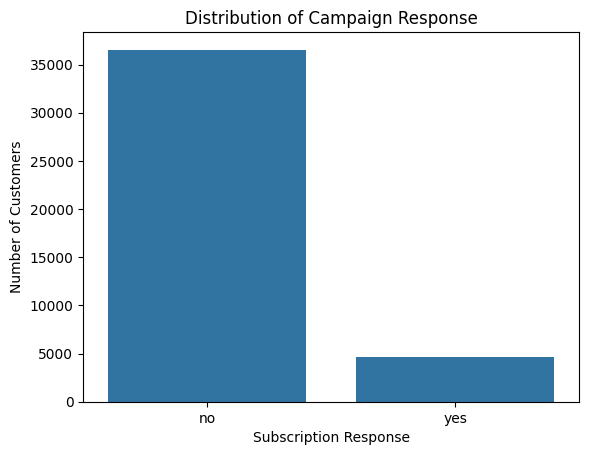

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=df, x='y')

plt.title("Distribution of Campaign Response")
plt.xlabel("Subscription Response")
plt.ylabel("Number of Customers")

plt.show()

In [15]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


Numerical Feature Summary
The descriptive statistics provide an overview of the numerical variables in the Bank Marketing dataset, including their distribution, central tendency, and range.

The dataset contains 41,188 records, and all numerical variables have complete observations.

Key observations:

The average customer age is approximately 40 years, with ages ranging from 17 to 98 years.
The duration feature has a wide range, from 0 to 4918 seconds, indicating high variation in call durations and possible outliers.
The campaign feature shows that customers were contacted an average of approximately 2–3 times during the current campaign, although some customers received many contacts.
The pdays feature contains many values of 999, which represents customers who were not previously contacted.
The previous feature indicates that most customers had limited previous campaign interactions.
Economic variables such as emp.var.rate, cons.price.idx, cons.conf.idx, euribor3m, and nr.employed provide information about the economic conditions during the campaign period.


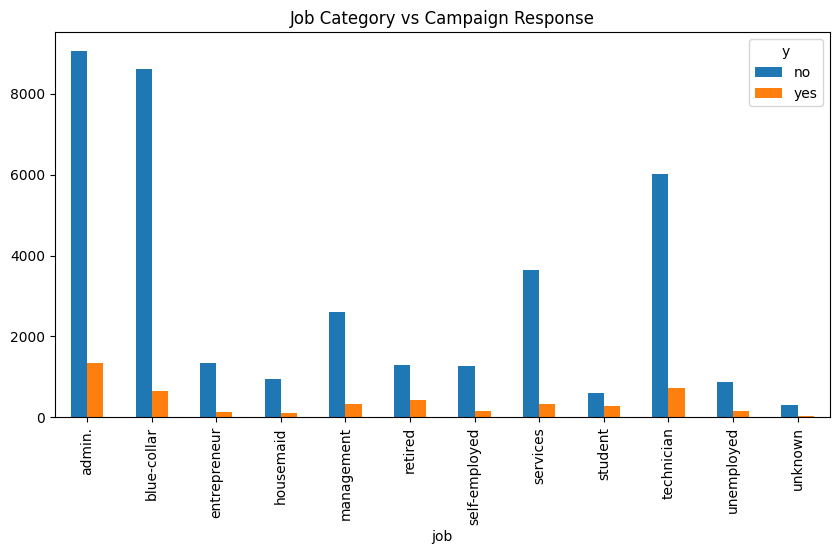

In [16]:
pd.crosstab(
    df['job'],
    df['y']
).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Job Category vs Campaign Response")
plt.show()

In [17]:
job_response_rate = pd.crosstab(
    df['job'],
    df['y'],
    normalize='index'
) * 100

job_response_rate

y,no,yes
job,,
admin.,87.027442,12.972558
blue-collar,93.105684,6.894316
entrepreneur,91.483516,8.516484
housemaid,90.000000,10.000000
management,88.782490,11.217510
retired,74.767442,25.232558
self-employed,89.514426,10.485574
services,91.861930,8.138070
student,68.571429,31.428571


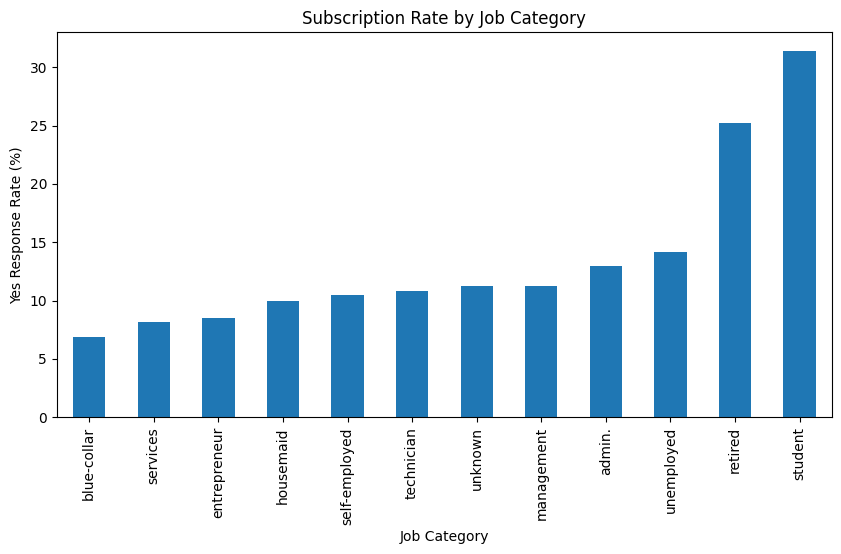

In [18]:
job_response_rate['yes'].sort_values().plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Subscription Rate by Job Category")
plt.xlabel("Job Category")
plt.ylabel("Yes Response Rate (%)")

plt.show()

### Job Category vs Campaign Response

The relationship between customer job category and campaign response was explored to identify whether occupation influences subscription behaviour.

The analysis shows that response counts vary across job categories. However, since the dataset contains class imbalance, the number of successful responses alone may be misleading. Therefore, response rates within each job category should also be considered.

This analysis helps identify whether customer occupation can be a useful feature for predicting campaign response.

In [21]:
pd.crosstab(
    df['poutcome'],
    df['y']
)

y,no,yes
poutcome,,
failure,3647,605
nonexistent,32422,3141
success,479,894


In [22]:
poutcome_response_rate = pd.crosstab(
    df['poutcome'],
    df['y'],
    normalize='index'
) * 100

poutcome_response_rate

y,no,yes
poutcome,,
failure,85.771402,14.228598
nonexistent,91.167787,8.832213
success,34.887109,65.112891


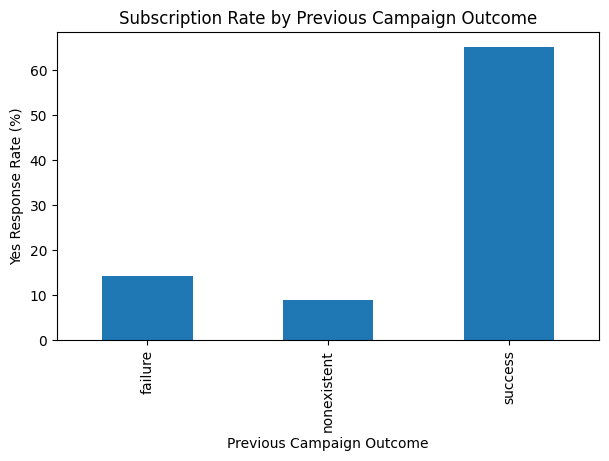

In [23]:
poutcome_response_rate['yes'].plot(
    kind='bar',
    figsize=(7,4)
)

plt.title("Subscription Rate by Previous Campaign Outcome")
plt.xlabel("Previous Campaign Outcome")
plt.ylabel("Yes Response Rate (%)")

plt.show()